# EvidenceLab — 02 · Full SFT Phi-4-mini — Colab T4 FINAL

**Modelo:** `microsoft/Phi-4-mini-instruct`

Esta es la versión limpia y definitiva después de las pruebas de memoria.

- Full fine-tuning real: **100% de parámetros entrenables**
- `SFTTrainer`
- `packing=True`
- completion-only loss
- AdaLomo
- `MAX_LENGTH=512` por limitación de T4
- sin `truncation_mode`
- solo se usan ejemplos cuya secuencia completa cabe en 512 tokens
- train esperado: **300 ejemplos**
- validation esperado: **59 ejemplos**
- búsqueda LR: `1e-5`, `5e-5`, `1e-4`
- cinco prompts antes/después
- MLflow y guardado final en Drive

El dataset EvidenceLab v1.0 no se modifica; esta selección solo se usa para el experimento SFT.

## Antes de ejecutar

1. Activa **T4 GPU**.
2. Ejecuta las celdas en orden.
3. **Detente después del smoke test 512** y verifica que aparezca `SMOKE TEST 512 OK`.
4. Solo entonces continúa al learning-rate search.

In [1]:
!pip -q install -U "transformers<5" datasets accelerate "trl>=0.23,<1" lomo-optim mlflow pandas matplotlib psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import psutil

assert torch.cuda.is_available(), "Activa una GPU T4 en Colab."

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
RAM_GB = psutil.virtual_memory().total / 1024**3

print("GPU:", GPU_NAME)
print(f"VRAM: {VRAM_GB:.2f} GB")
print(f"RAM host: {RAM_GB:.2f} GB")
print("CUDA:", torch.version.cuda)
print("PyTorch:", torch.__version__)

GPU: Tesla T4
VRAM: 14.56 GB
RAM host: 12.67 GB
CUDA: 12.8
PyTorch: 2.11.0+cu128


In [3]:
from google.colab import drive, files
from pathlib import Path
import zipfile

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/EvidenceLab")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

ZIP_IN_DRIVE = DRIVE_ROOT / "EvidenceLab_Criminal_ES_v1_0.zip"
DATA_DIR = Path("/content/EvidenceLab_Criminal_ES_v1_0")

if not DATA_DIR.exists():
    if ZIP_IN_DRIVE.exists():
        zip_path = ZIP_IN_DRIVE
    else:
        print("Selecciona EvidenceLab_Criminal_ES_v1_0.zip")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No se subió ningún ZIP.")
        zip_path = Path("/content") / next(iter(uploaded))

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")

    if not DATA_DIR.exists():
        matches = list(Path("/content").rglob("EvidenceLab_Criminal_ES_v1_0"))
        if not matches:
            raise FileNotFoundError("No encontré EvidenceLab_Criminal_ES_v1_0.")
        DATA_DIR = matches[0]

print("DATA_DIR:", DATA_DIR)

Mounted at /content/drive
DATA_DIR: /content/EvidenceLab_Criminal_ES_v1_0


In [5]:
import gc, json, time
from pathlib import Path

import torch
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import os

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from trl import SFTTrainer, SFTConfig

SEED = 42
set_seed(SEED)

MODEL_NAME = "microsoft/Phi-4-mini-instruct"
MAX_LENGTH = 512
TRAIN_BATCH = 1
EVAL_BATCH = 1
GRAD_ACCUM = 1

LR_VALUES = [1e-5, 5e-5, 1e-4]
LR_SEARCH_MAX_STEPS = 8
FINAL_EPOCHS = 1

DRIVE_ARTIFACTS = DRIVE_ROOT / "artifacts" / "02_phi_full_sft"
DRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)

MLRUNS_DIR = DRIVE_ROOT / "mlruns"
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true" # Add this line to allow filesystem backend
mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
mlflow.set_experiment("EvidenceLab_Phi4_FullSFT_AdaLomo")

print("MAX_LENGTH:", MAX_LENGTH)
print("Optimizer: AdaLomo")

MAX_LENGTH: 512
Optimizer: AdaLomo


In [6]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

train_rows = load_jsonl(DATA_DIR / "training" / "final" / "train.jsonl")
val_rows = load_jsonl(DATA_DIR / "training" / "final" / "validation.jsonl")
test_rows = load_jsonl(DATA_DIR / "training" / "final" / "test.jsonl")

assert len(train_rows) == 387
assert len(val_rows) == 76
assert len(test_rows) == 137

def to_prompt_completion(row):
    messages = row["messages"]
    return {
        "prompt": messages[:-1],
        "completion": [messages[-1]],
        "example_id": row["example_id"],
        "task": row["task"],
        "case_id": row["case_id"],
    }

train_ds = Dataset.from_list([to_prompt_completion(x) for x in train_rows])
val_ds = Dataset.from_list([to_prompt_completion(x) for x in val_rows])
test_ds = Dataset.from_list([to_prompt_completion(x) for x in test_rows])

print(train_ds)

Dataset({
    features: ['prompt', 'completion', 'example_id', 'task', 'case_id'],
    num_rows: 387
})


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


def sequence_stats(row):
    full_ids = tokenizer.apply_chat_template(
        row["messages"],
        tokenize=True,
        add_generation_prompt=False,
    )
    prompt_ids = tokenizer.apply_chat_template(
        row["messages"][:-1],
        tokenize=True,
        add_generation_prompt=True,
    )
    return {
        "total_tokens": len(full_ids),
        "prompt_tokens": len(prompt_ids),
        "completion_tokens": max(len(full_ids) - len(prompt_ids), 0),
    }


def select_complete(rows, max_length):
    selected = []
    manifest = []
    for row in rows:
        stats = sequence_stats(row)
        keep = stats["total_tokens"] <= max_length
        manifest.append({
            "example_id": row["example_id"],
            "task": row["task"],
            **stats,
            "selected": keep,
        })
        if keep:
            selected.append(row)
    return selected, pd.DataFrame(manifest)


train_rows_sft, train_manifest = select_complete(train_rows, MAX_LENGTH)
val_rows_sft, val_manifest = select_complete(val_rows, MAX_LENGTH)

train_ds = Dataset.from_list([to_prompt_completion(x) for x in train_rows_sft])
val_ds = Dataset.from_list([to_prompt_completion(x) for x in val_rows_sft])
test_ds = Dataset.from_list([to_prompt_completion(x) for x in test_rows])

print("Train original:", len(train_rows))
print("Train SFT completo <=512:", len(train_ds))
print("Validation original:", len(val_rows))
print("Validation SFT completo <=512:", len(val_ds))
print("Test reservado:", len(test_ds))

assert len(train_ds) >= 300
assert len(val_ds) >= 50

selection_manifest = pd.concat([
    train_manifest.assign(split="train"),
    val_manifest.assign(split="validation"),
], ignore_index=True)
selection_manifest.to_csv(
    DRIVE_ARTIFACTS / "sft_selection_manifest.csv",
    index=False,
)

wanted_tasks = [
    "claim_verification",
    "theory_assessment",
    "contradiction_analysis",
    "responsibility_reasoning",
    "case_reconstruction",
]

fixed_examples = []
used = set()
for row in test_rows:
    if row["task"] in wanted_tasks and row["task"] not in used:
        fixed_examples.append(row)
        used.add(row["task"])
    if len(fixed_examples) == 5:
        break

if len(fixed_examples) < 5:
    selected = {x["example_id"] for x in fixed_examples}
    for row in test_rows:
        if row["example_id"] not in selected:
            fixed_examples.append(row)
        if len(fixed_examples) == 5:
            break

[(x["example_id"], x["task"]) for x in fixed_examples]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

Train original: 387
Train SFT completo <=512: 300
Validation original: 76
Validation SFT completo <=512: 59
Test reservado: 137


[('CASE-MX-006-VERIFY-001', 'claim_verification'),
 ('CASE-MX-006-THEORY-001', 'theory_assessment'),
 ('CASE-MX-006-CONTRA-001', 'contradiction_analysis'),
 ('CASE-MX-006-RESP-001', 'responsibility_reasoning'),
 ('CASE-MX-006-RECONSTRUCTION', 'case_reconstruction')]

In [8]:
def generate_from_messages(model, prompt_messages, max_new_tokens=220):
    model.eval()
    inputs = tokenizer.apply_chat_template(
        prompt_messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = output[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

## 1. Cinco outputs antes del SFT

In [9]:
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
    attn_implementation="sdpa",
).cuda()

baseline_outputs = []
for row in fixed_examples:
    text = generate_from_messages(baseline_model, row["messages"][:-1])
    baseline_outputs.append({
        "example_id": row["example_id"],
        "task": row["task"],
        "before": text,
        "expected": json.dumps(row["expected_output"], ensure_ascii=False),
    })

display(pd.DataFrame(baseline_outputs)[["example_id", "task", "before"]])

pd.DataFrame(baseline_outputs).to_csv(
    DRIVE_ARTIFACTS / "baseline_five_prompts.csv",
    index=False,
)

del baseline_model
gc.collect()
torch.cuda.empty_cache()
print(f"RAM host usada tras baseline: {psutil.virtual_memory().percent:.1f}%")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

,example_id,task,before
0,CASE-MX-006-VERIFY-001,claim_verification,La afirmación está respaldada por la evidencia...
1,CASE-MX-006-THEORY-001,theory_assessment,A favor de la teoría: La primera declaración d...
2,CASE-MX-006-CONTRA-001,contradiction_analysis,"Basado en la evidencia proporcionada, hay una ..."
3,CASE-MX-006-RESP-001,responsibility_reasoning,Hechos:\n1. La versión incriminatoria del test...
4,CASE-MX-006-RECONSTRUCTION,case_reconstruction,Cronología de los eventos del caso:\n\n1. Inci...


RAM host usada tras baseline: 42.9%


## 2. Full SFT de baja memoria con AdaLomo

AdaLomo fusiona cálculo de gradiente y actualización de parámetros para reducir memoria. No usamos DeepSpeed ni CPU offload.

In [10]:
def make_config(
    output_dir,
    learning_rate,
    *,
    max_steps=-1,
    epochs=1,
    run_name="phi-full-adalomo",
):
    return SFTConfig(
        output_dir=str(output_dir),
        max_length=MAX_LENGTH,
        packing=True,
        packing_strategy="wrapped",
        padding_free=False,
        eval_packing=False,
        completion_only_loss=True,
        num_train_epochs=epochs,
        max_steps=max_steps,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=learning_rate,
        optim="adalomo",
        max_grad_norm=0.0,
        lr_scheduler_type="constant",
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        # IMPORTANTE: los pesos siguen en FP16, pero se desactiva
        # GradScaler de Trainer para que AdaLomo maneje su backward.
        fp16=False,
        bf16=False,
        eval_strategy="no",
        logging_strategy="steps",
        logging_steps=1,
        save_strategy="no",
        report_to=[],
        seed=SEED,
        data_seed=SEED,
        run_name=run_name,
    )


def load_full_model():
    gc.collect()
    torch.cuda.empty_cache()

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float16,
        low_cpu_mem_usage=True,
        attn_implementation="sdpa",
    )
    model.config.use_cache = False

    for p in model.parameters():
        p.requires_grad = True

    model = model.cuda()

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100 * trainable / total
    print(f"Trainable: {trainable:,} / {total:,} = {pct:.2f}%")
    assert trainable == total
    return model

In [11]:
# SMOKE TEST 512: 1 solo paso. NO sigas al LR search si falla.
smoke_model = load_full_model()
smoke_ds = train_ds.select(range(min(16, len(train_ds))))

smoke_trainer = SFTTrainer(
    model=smoke_model,
    args=make_config(
        "/content/phi_smoke_512",
        learning_rate=1e-5,
        max_steps=1,
        epochs=1,
        run_name="phi-smoke-512",
    ),
    train_dataset=smoke_ds,
    processing_class=tokenizer,
)

torch.cuda.reset_peak_memory_stats()
start = time.perf_counter()
smoke_result = smoke_trainer.train()
smoke_time = time.perf_counter() - start
smoke_peak = torch.cuda.max_memory_allocated() / 1024**3

print("")
print("SMOKE TEST 512 OK")
print(f"Loss: {smoke_result.training_loss:.4f}")
print(f"Tiempo: {smoke_time:.2f} s")
print(f"VRAM pico: {smoke_peak:.2f} GB")
print(f"RAM host usada: {psutil.virtual_memory().percent:.1f}%")

del smoke_trainer, smoke_model
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable: 3,836,021,760 / 3,836,021,760 = 100.00%


Tokenizing train dataset:   0%|          | 0/16 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/16 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/trainer.py:2750: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.lr_scheduler.step()


Step,Training Loss
1,3.741200



SMOKE TEST 512 OK
Loss: 3.7412
Tiempo: 3.87 s
VRAM pico: 14.04 GB
RAM host usada: 36.7%


## 3. Búsqueda de learning rate

Ejecuta esta sección **solo si el smoke test 512 terminó con `SMOKE TEST 512 OK`**.

Cada learning rate parte del checkpoint original y se evalúa sobre los ejemplos de validation que caben completos en 512 tokens.

In [12]:
search_train_ds = train_ds.select(range(min(120, len(train_ds))))
search_val_ds = val_ds

lr_results = []

for lr in LR_VALUES:
    print("\n" + "=" * 60)
    print("LR =", lr)

    model = load_full_model()

    trainer = SFTTrainer(
        model=model,
        args=make_config(
            f"/content/phi_lr_{lr}",
            learning_rate=lr,
            max_steps=LR_SEARCH_MAX_STEPS,
            epochs=1,
            run_name=f"phi-lr-{lr}",
        ),
        train_dataset=search_train_ds,
        eval_dataset=search_val_ds,
        processing_class=tokenizer,
    )

    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()

    with mlflow.start_run(run_name=f"phi-adalomo-lr-{lr}"):
        mlflow.log_params({
            "model": MODEL_NAME,
            "optimizer": "adalomo",
            "learning_rate": lr,
            "max_length": MAX_LENGTH,
            "packing": True,
            "completion_only_loss": True,
            "full_finetuning": True,
            "search_steps": LR_SEARCH_MAX_STEPS,
            "train_examples": len(search_train_ds),
            "validation_examples": len(search_val_ds),
        })
        train_result = trainer.train()
        metrics = trainer.evaluate()

    elapsed = time.perf_counter() - start
    peak = torch.cuda.max_memory_allocated() / 1024**3
    eval_loss = float(metrics["eval_loss"])

    lr_results.append({
        "learning_rate": lr,
        "train_loss": float(train_result.training_loss),
        "eval_loss": eval_loss,
        "time_seconds": elapsed,
        "peak_vram_gb": peak,
    })

    print("Eval loss:", eval_loss)

    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()

lr_df = pd.DataFrame(lr_results)

if lr_df["eval_loss"].isna().any():
    raise RuntimeError("Hay eval_loss NaN. NO seleccionar learning rate.")

lr_df = lr_df.sort_values("eval_loss")
display(lr_df)

BEST_LR = float(lr_df.iloc[0]["learning_rate"])
print("Mejor LR:", BEST_LR)

lr_df.to_csv(DRIVE_ARTIFACTS / "learning_rate_search.csv", index=False)


LR = 1e-05


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable: 3,836,021,760 / 3,836,021,760 = 100.00%


Tokenizing train dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/trainer.py:2750: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.lr_scheduler.step()


Step,Training Loss
1,3.143500
2,3.111300
3,1.870100
4,3.022100
5,1.652900
6,1.174500
7,1.157600
8,1.145000


Eval loss: 1.5948357582092285


,learning_rate,train_loss,eval_loss,time_seconds,peak_vram_gb
2,0.00010,2.034619,1.594836,39.869679,14.037312
1,0.00005,2.863170,2.015232,41.204209,14.037312
0,0.00001,3.841837,3.199722,37.991763,14.037312


Mejor LR: 0.0001


## 4. Full SFT final — 1 época

In [13]:
FINAL_DIR = DRIVE_ARTIFACTS / "phi4_full_sft_adalomo"

model = load_full_model()

trainer = SFTTrainer(
    model=model,
    args=make_config(
        "/content/phi_final",
        learning_rate=BEST_LR,
        max_steps=-1,
        epochs=FINAL_EPOCHS,
        run_name="phi-full-final",
    ),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
)

torch.cuda.reset_peak_memory_stats()
start = time.perf_counter()

with mlflow.start_run(run_name="phi-full-final-adalomo"):
    mlflow.log_params({
        "model": MODEL_NAME,
        "optimizer": "adalomo",
        "learning_rate": BEST_LR,
        "max_length": MAX_LENGTH,
        "packing": True,
        "completion_only_loss": True,
        "full_finetuning": True,
        "train_examples": len(train_ds),
        "validation_examples": len(val_ds),
        "epochs": FINAL_EPOCHS,
    })
    train_output = trainer.train()
    final_eval = trainer.evaluate()

elapsed = time.perf_counter() - start
peak_vram = torch.cuda.max_memory_allocated() / 1024**3
final_eval_loss = float(final_eval["eval_loss"])

print("Final eval loss:", final_eval_loss)
print(f"Tiempo: {elapsed/60:.2f} min")
print(f"VRAM pico: {peak_vram:.2f} GB")
print(f"RAM host usada: {psutil.virtual_memory().percent:.1f}%")

trainer.model.save_pretrained(
    FINAL_DIR,
    safe_serialization=True,
    max_shard_size="4GB",
)
tokenizer.save_pretrained(FINAL_DIR)
print("Modelo guardado en:", FINAL_DIR)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable: 3,836,021,760 / 3,836,021,760 = 100.00%


Tokenizing train dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/59 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/59 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/trainer.py:2750: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.lr_scheduler.step()


Step,Training Loss
1,3.824000
2,1.452000
3,3.797900
4,1.657400
5,2.480500
6,1.451600
7,0.594200
8,1.696200
9,1.356300
10,1.366400


Final eval loss: 0.13694490492343903
Tiempo: 9.35 min
VRAM pico: 14.04 GB
RAM host usada: 35.5%
Modelo guardado en: /content/drive/MyDrive/EvidenceLab/artifacts/02_phi_full_sft/phi4_full_sft_adalomo


## 5. Cinco comparaciones antes/después

In [14]:
after_outputs = []

for row, before in zip(fixed_examples, baseline_outputs):
    after_text = generate_from_messages(
        trainer.model,
        row["messages"][:-1],
    )

    after_outputs.append({
        "example_id": row["example_id"],
        "task": row["task"],
        "before": before["before"],
        "after": after_text,
        "expected": before["expected"],
    })

comparison_df = pd.DataFrame(after_outputs)
display(comparison_df)

comparison_df.to_csv(
    DRIVE_ARTIFACTS / "five_prompts_before_after.csv",
    index=False,
)

,example_id,task,before,after,expected
0,CASE-MX-006-VERIFY-001,claim_verification,La afirmación está respaldada por la evidencia...,"{""verdict"": ""supported"", ""reason"": ""La clasifi...","{""verdict"": ""supported"", ""reason"": ""La clasifi..."
1,CASE-MX-006-THEORY-001,theory_assessment,A favor de la teoría: La primera declaración d...,"{""assessment"": ""contradicted"", ""supporting_ele...","{""assessment"": ""contradicted"", ""supporting_ele..."
2,CASE-MX-006-CONTRA-001,contradiction_analysis,"Basado en la evidencia proporcionada, hay una ...","{""relation"": ""tension_or_contradiction"", ""expl...","{""relation"": ""tension_or_contradiction"", ""expl..."
3,CASE-MX-006-RESP-001,responsibility_reasoning,Hechos:\n1. La versión incriminatoria del test...,"{""official_outcome"": ""revocacion_por_presuncio...","{""official_outcome"": ""revocacion_por_presuncio..."
4,CASE-MX-006-RECONSTRUCTION,case_reconstruction,Cronología de los eventos del caso:\n\n1. Inci...,"{""temporal_relation"": ""BEFORE"", ""first_event_i...","{""case_title"": ""Homicidio con testigo retracta..."


In [15]:
import json


def parse_json_safe(value):
    if isinstance(value, dict):
        return value

    try:
        return json.loads(value)
    except Exception:
        return None


for _, row in comparison_df.iterrows():

    print("\n" + "=" * 90)
    print("EXAMPLE:", row["example_id"])
    print("TASK:", row["task"])

    print("\n--- BEFORE ---")
    print(row["before"])

    print("\n--- AFTER ---")
    print(row["after"])

    print("\n--- EXPECTED ---")
    print(row["expected"])

    after_json = parse_json_safe(
        row["after"]
    )

    expected_json = parse_json_safe(
        row["expected"]
    )

    print("\n--- STRUCTURE ---")

    if (
        after_json is not None
        and expected_json is not None
    ):
        after_keys = set(
            after_json.keys()
        )

        expected_keys = set(
            expected_json.keys()
        )

        print(
            "After keys:",
            sorted(after_keys),
        )

        print(
            "Expected keys:",
            sorted(expected_keys),
        )

        print(
            "Mismas keys:",
            after_keys
            == expected_keys,
        )

        print(
            "JSON exacto:",
            after_json
            == expected_json,
        )

    else:
        print(
            "No se pudo comparar "
            "como JSON."
        )


EXAMPLE: CASE-MX-006-VERIFY-001
TASK: claim_verification

--- BEFORE ---
La afirmación está respaldada por la evidencia proporcionada. La proposición con el id "CASE-MX-006-P1" afirma que el testigo implicó a la persona acusada en su primera declaración, lo cual coincide con la afirmación.

--- AFTER ---
{"verdict": "supported", "reason": "La clasificación se limita a la proposición y su modalidad; no se añade información externa.", "proposition_ids": ["CASE-MX-006-P1"], "source": {"document_id": "CASE-MX-006-DOC-001", "page_number": 7}, "limitations": ["La resolución judicial puede resumir pruebas que no se publican íntegramente."]}

--- EXPECTED ---
{"verdict": "supported", "reason": "La clasificación se limita a la proposición y su modalidad; no se añade información externa.", "proposition_ids": ["CASE-MX-006-P1"], "source": {"document_id": "CASE-MX-006-DOC-001", "page_number": 7}, "limitations": ["La resolución judicial puede resumir pruebas que no se publican íntegramente."]}

--

## 6. Curva de training loss

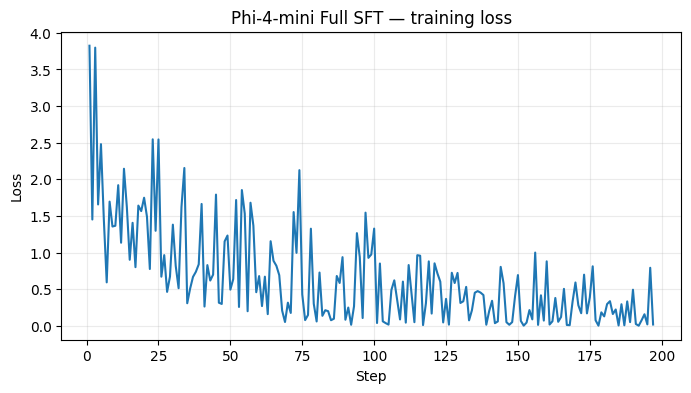

,loss,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy
194,0.0205,0.0001,0.817383,99547.0,1.000000,0.989848,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
195,0.7933,0.0001,0.987793,100059.0,0.841176,0.994924,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,0.0187,0.0001,0.770508,100571.0,0.993750,1.000000,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197,NaN,NaN,NaN,NaN,NaN,1.000000,197,543.5747,0.362,0.362,1.943892e+15,0.656083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198,NaN,NaN,NaN,NaN,NaN,1.000000,197,NaN,NaN,NaN,NaN,NaN,0.136945,16.3844,3.601,3.601,1.033625,100571.0,0.971953


In [16]:
history = pd.DataFrame(trainer.state.log_history)
history.to_csv(DRIVE_ARTIFACTS / "trainer_log_history.csv", index=False)

train_hist = history.dropna(subset=["loss"]) if "loss" in history.columns else pd.DataFrame()
if not train_hist.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_hist["step"], train_hist["loss"])
    ax.set_title("Phi-4-mini Full SFT — training loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(alpha=.25)
    plt.show()

display(history.tail())

## 7. Exportar métricas para la tabla Full vs LoRA vs QLoRA

In [17]:
full_metrics = {
    "technique": "Full SFT",
    "optimizer": "AdaLomo",
    "model": MODEL_NAME,
    "gpu": GPU_NAME,
    "max_length": MAX_LENGTH,
    "learning_rate": BEST_LR,
    "original_train_examples": len(train_rows),
    "sft_train_examples": len(train_ds),
    "original_validation_examples": len(val_rows),
    "sft_validation_examples": len(val_ds),
    "eval_loss": final_eval_loss,
    "time_seconds": elapsed,
    "peak_vram_gb": peak_vram,
    "trainable_percentage": 100.0,
}

with (DRIVE_ARTIFACTS / "full_sft_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(full_metrics, f, ensure_ascii=False, indent=2)

full_metrics

{'technique': 'Full SFT',
 'optimizer': 'AdaLomo',
 'model': 'microsoft/Phi-4-mini-instruct',
 'gpu': 'Tesla T4',
 'max_length': 512,
 'learning_rate': 0.0001,
 'original_train_examples': 387,
 'sft_train_examples': 300,
 'original_validation_examples': 76,
 'sft_validation_examples': 59,
 'eval_loss': 0.13694490492343903,
 'time_seconds': 560.7248018320001,
 'peak_vram_gb': 14.037312030792236,
 'trainable_percentage': 100.0}

## Conclusión a completar

Al finalizar:

- reporta el learning rate con menor `eval_loss`;
- compara los cinco prompts antes/después;
- documenta tiempo y VRAM del full SFT;
- explica que `MAX_LENGTH=512` fue una adaptación a la T4;
- documenta que se usaron exclusivamente secuencias completas para evitar perder la completion;
- conserva `full_sft_metrics.json`, porque el Notebook 03 lo utilizará para la tabla Full SFT vs LoRA vs QLoRA.

In [18]:
print("=" * 90)
print("CASE RECONSTRUCTION — TRAIN")
print("=" * 90)

reconstruction_rows = [
    row
    for row in train_rows_sft
    if row["task"] == "case_reconstruction"
]

print(
    "Cantidad:",
    len(reconstruction_rows),
)

for row in reconstruction_rows:
    print("\n" + "-" * 90)
    print("ID:", row["example_id"])
    print("INSTRUCTION:")
    print(row["instruction"])

    print("\nUSER MESSAGE:")
    print(
        row["messages"][-2]["content"]
    )

    print("\nEXPECTED OUTPUT:")
    print(
        json.dumps(
            row["expected_output"],
            ensure_ascii=False,
            indent=2,
        )
    )


print("\n\n")
print("=" * 90)
print("TEMPORAL RELATION — MUESTRA")
print("=" * 90)

temporal_rows = [
    row
    for row in train_rows_sft
    if row["task"]
    == "temporal_relation_reasoning"
]

print(
    "Cantidad:",
    len(temporal_rows),
)

for row in temporal_rows[:3]:
    print("\n" + "-" * 90)
    print("ID:", row["example_id"])
    print("INSTRUCTION:")
    print(row["instruction"])

    print("\nUSER MESSAGE:")
    print(
        row["messages"][-2]["content"]
    )

    print("\nEXPECTED OUTPUT:")
    print(
        json.dumps(
            row["expected_output"],
            ensure_ascii=False,
            indent=2,
        )
    )

CASE RECONSTRUCTION — TRAIN
Cantidad: 0



TEMPORAL RELATION — MUESTRA
Cantidad: 29

------------------------------------------------------------------------------------------
ID: REL-c8caa62f2a-TEMP
INSTRUCTION:
Determina la relación temporal entre los dos eventos y explica el orden.

USER MESSAGE:
{"instruction": "Determina la relación temporal entre los dos eventos y explica el orden.", "input": {"event_a": {"event_id": "CASE-MX-001-E1", "description": "La víctima salió de su domicilio para encontrarse con la persona acusada.", "time_expression": "2012-06-11 21:50"}, "event_b": {"event_id": "CASE-MX-001-E2", "description": "Ambas personas llegaron al hotel e ingresaron a una habitación.", "time_expression": "2012-06-11 22:10"}}}

EXPECTED OUTPUT:
{
  "temporal_relation": "BEFORE",
  "first_event": "CASE-MX-001-E1",
  "second_event": "CASE-MX-001-E2",
  "reason": "La relación temporal anotada indica que el primer evento ocurrió antes que el segundo.",
  "rule_id": "RULE-TEMP-TRANSITI